# 04. Lane Extraction Method Sample Review

이 노트북의 목적은 04번에서 비교했던 4가지 pseudo-label 추출 방법을 더 엄밀하게 다시 비교해서, 이후 CULane 형식 데이터셋 빌더에 사용할 기본 method를 결정하는 것이다.

기존 04번의 문제는 두 가지였다.

- 씬당 5장만 보았기 때문에 시각 검수 샘플이 부족했음.
- 자동 점수에서 `two_lane` 개수를 너무 크게 보아, 실제로는 같은 물리 노란선에 초록/빨강이 섞이는 위험을 충분히 벌점으로 주지 못했음.

따라서 여기서는 샘플 수를 늘리고, 점수 기준을 `coverage`, `mask support`, `component consistency`, `geometry risk`, `scene balance`로 나누어 본다.


In [1]:
from __future__ import annotations

import csv
import json
import math
import sys
from collections import defaultdict
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

PIPELINE_ROOT = Path(r"~/02_Projects/University/26-1_EmbeddedArtificialSystemOptimization/10_experiments/05_lane_finetune_dataset_pipeline")
sys.path.insert(0, str(PIPELINE_ROOT / "src"))

import pipeline_common as pc

pc.ensure_dirs(pc.OUTPUTS, pc.REPORTS, PIPELINE_ROOT / "configs")

CONFIG_V1 = PIPELINE_ROOT / "configs" / "field2_builder_v1_hsv.json"
with CONFIG_V1.open("r", encoding="utf-8") as f:
    base_config = json.load(f)

HSV_CFG = base_config["hsv"]
MANIFEST_PATH = pc.MANIFESTS / "01_lane_drive_capture_manifest.csv"
print("pipeline root:", PIPELINE_ROOT)
print("manifest:", MANIFEST_PATH)
print("hsv:", HSV_CFG)


pipeline root: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\05_lane_finetune_dataset_pipeline
manifest: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\04_field2_map_lab\field2_experiment\data\20260501_field2\manifests\01_lane_drive_capture_manifest.csv
hsv: {'lower': [22, 90, 110], 'upper': [38, 255, 255], 'morph_kernel': 5}


## 1. 비교할 샘플셋 확장

04번에서는 씬당 5장, 총 45장만 method metric에 사용했다. 이번에는 씬당 12장, 총 108장을 사용한다.

`straight`처럼 쉬운 구간만 잘 맞는 method를 피하기 위해, `curve`, `off-center`, `intersection`, `failure_cases`까지 균형 있게 넣는다. 여기서 `failure_cases`는 학습에 바로 넣기 위한 후보라기보다, method가 깨지는 방식을 보기 위한 stress test에 가깝다.


In [2]:
SCENE_ORDER = [
    "straight",
    "left_curve",
    "right_curve",
    "off_center_left",
    "off_center_right",
    "intersection_approach",
    "intersection_left",
    "intersection_right",
    "failure_cases",
]
EVAL_PER_SCENE = 12
VISUAL_PER_SCENE = 3

with MANIFEST_PATH.open("r", encoding="utf-8", newline="") as f:
    manifest = list(csv.DictReader(f))

valid_rows = []
for row in manifest:
    local = pc.pi_path_to_local(row.get("raw_path", ""))
    if local is not None and pc.path_exists(local):
        row = dict(row)
        row["local_raw_path"] = str(local)
        valid_rows.append(row)

by_scene = defaultdict(list)
for row in valid_rows:
    by_scene[row.get("label", "unknown")].append(row)

sample_rows = []
visual_rows = []
for scene in SCENE_ORDER:
    rows = by_scene.get(scene, [])
    sample_rows.extend(pc.pick_evenly(rows, EVAL_PER_SCENE))
    visual_rows.extend(pc.pick_evenly(rows, VISUAL_PER_SCENE))

scene_summary = pd.DataFrame([
    {
        "scene": scene,
        "available": len(by_scene.get(scene, [])),
        "eval_used": len([r for r in sample_rows if r["label"] == scene]),
        "visual_used": len([r for r in visual_rows if r["label"] == scene]),
    }
    for scene in SCENE_ORDER
])
display(scene_summary)
print("eval samples:", len(sample_rows))
print("visual samples:", len(visual_rows))


,scene,available,eval_used,visual_used
0,straight,57,12,3
1,left_curve,227,12,3
2,right_curve,231,12,3
3,off_center_left,344,12,3
4,off_center_right,455,12,3
5,intersection_approach,93,12,3
6,intersection_left,285,12,3
7,intersection_right,287,12,3
8,failure_cases,488,12,3


eval samples: 108
visual samples: 27


## 2. 비교할 4가지 method

네 방법은 모두 원본 이미지에서 직접 차선을 새로 찾는 것이 아니라, 03번에서 확정한 HSV 노란색 마스크를 입력으로 받는다. 차이는 마스크 픽셀을 공식 CULane `.lines.txt` 좌표로 바꾸는 방식이다.

- `rowwise`: 각 y-row마다 왼쪽/오른쪽 mask run을 독립적으로 고름.
- `rowwise_poly`: rowwise 결과를 polynomial fitting으로 부드럽게 함.
- `sliding_window_poly`: 아래쪽에서 위쪽으로 올라가며 이전 x 위치에 가까운 run을 추적함.
- `component_poly`: connected component 단위로 노란 덩어리를 고른 뒤, 각 component를 lane curve로 fitting함.


In [3]:
METHOD_CONFIGS = {
    "rowwise": {"method": "rowwise", "y_step": 8, "min_run_width": 4, "min_points": 8},
    "rowwise_poly": {"method": "rowwise_poly", "y_step": 8, "min_run_width": 4, "min_points": 8, "degree": 2},
    "sliding_window_poly": {"method": "sliding_window_poly", "y_step": 8, "min_run_width": 4, "min_points": 8, "search_radius": 90.0, "smooth_alpha": 0.25, "degree": 2},
    "component_poly": {"method": "component_poly", "y_step": 8, "min_run_width": 4, "min_points": 8, "min_area": 250, "min_height": 80, "degree": 2},
}
print(json.dumps(METHOD_CONFIGS, indent=2, ensure_ascii=False))


{
  "rowwise": {
    "method": "rowwise",
    "y_step": 8,
    "min_run_width": 4,
    "min_points": 8
  },
  "rowwise_poly": {
    "method": "rowwise_poly",
    "y_step": 8,
    "min_run_width": 4,
    "min_points": 8,
    "degree": 2
  },
  "sliding_window_poly": {
    "method": "sliding_window_poly",
    "y_step": 8,
    "min_run_width": 4,
    "min_points": 8,
    "search_radius": 90.0,
    "smooth_alpha": 0.25,
    "degree": 2
  },
  "component_poly": {
    "method": "component_poly",
    "y_step": 8,
    "min_run_width": 4,
    "min_points": 8,
    "min_area": 250,
    "min_height": 80,
    "degree": 2
  }
}


## 3. 품질 진단 기준 정의

자동 점수는 단순히 `두 선이 나왔다`만 보면 안 된다. CLRKDNet fine-tuning label로 쓰려면, 아래 위험을 특히 벌점으로 봐야 한다.

- 같은 물리 노란선을 초록/빨강 두 lane으로 중복 표기하는가?
- 두 lane의 좌우 순서가 뒤집히거나 교차하는가?
- 추출된 line이 실제 HSV mask 위에 충분히 놓이는가?
- y 방향으로 충분히 긴 구간을 커버하는가?
- 특정 scene에서만 잘 되고 다른 scene에서 무너지는가?

여기서 connected component label은 시각적 위험을 수치화하기 위한 보조 지표다. 두 출력 lane이 같은 component에 대부분 붙어 있으면, 같은 노란선에서 두 lane을 뽑았을 가능성이 높다.


In [4]:
def mask_for_row(row):
    rgb = pc.load_rgb(Path(row["local_raw_path"]))
    crop = pc.crop_road(rgb)
    mask_crop = pc.hsv_yellow_mask(crop, lower=tuple(HSV_CFG["lower"]), upper=tuple(HSV_CFG["upper"]), morph_kernel=int(HSV_CFG["morph_kernel"]))
    mask_raw = pc.crop_mask_to_raw(mask_crop)
    return rgb, mask_raw


def run_method(row, cfg):
    rgb, mask_raw = mask_for_row(row)
    method = cfg["method"]
    params = {k: v for k, v in cfg.items() if k != "method"}
    lanes, q = pc.extract_lanes_by_method(mask_raw, method=method, **params)
    lanes = sorted(lanes, key=lambda lane: np.median([p[0] for p in lane]) if lane else 1e9)
    return rgb, mask_raw, lanes, q


def point_component_id(labels, x, y, radius=5):
    h, w = labels.shape
    x = int(round(x)); y = int(round(y))
    x1 = max(0, x - radius); x2 = min(w, x + radius + 1)
    y1 = max(0, y - radius); y2 = min(h, y + radius + 1)
    patch = labels[y1:y2, x1:x2]
    vals = patch[patch > 0]
    if vals.size == 0:
        return 0
    ids, counts = np.unique(vals, return_counts=True)
    return int(ids[np.argmax(counts)])


def lane_component_stats(lane, labels):
    if not lane:
        return {"support_fraction": 0.0, "dominant_component": 0, "dominant_fraction": 0.0}
    ids = [point_component_id(labels, x, y) for x, y in lane]
    nonzero = [i for i in ids if i > 0]
    support = len(nonzero) / max(1, len(ids))
    if not nonzero:
        return {"support_fraction": support, "dominant_component": 0, "dominant_fraction": 0.0}
    vals, counts = np.unique(np.array(nonzero), return_counts=True)
    idx = int(np.argmax(counts))
    return {"support_fraction": float(support), "dominant_component": int(vals[idx]), "dominant_fraction": float(counts[idx] / max(1, len(nonzero)))}


def interpolate_x(lane, ys):
    pts = pc.sort_lane_bottom_to_top(lane)
    lane_y = np.array([p[1] for p in pts], dtype=np.float32)
    lane_x = np.array([p[0] for p in pts], dtype=np.float32)
    order = np.argsort(lane_y)
    return np.interp(ys, lane_y[order], lane_x[order])


def geometry_pair_stats(lanes):
    if len(lanes) < 2:
        return {"has_pair": 0.0, "median_gap": np.nan, "min_gap": np.nan, "crossing_risk": 0.0, "small_gap_risk": 0.0}
    left, right = lanes[0], lanes[1]
    y_min = max(min(p[1] for p in left), min(p[1] for p in right), pc.GEOM.cut_height)
    y_max = min(max(p[1] for p in left), max(p[1] for p in right), pc.GEOM.raw_height - 1)
    if y_max <= y_min + 10:
        return {"has_pair": 1.0, "median_gap": np.nan, "min_gap": np.nan, "crossing_risk": 1.0, "small_gap_risk": 1.0}
    ys = np.linspace(y_min, y_max, 32)
    lx = interpolate_x(left, ys)
    rx = interpolate_x(right, ys)
    gaps = rx - lx
    return {"has_pair": 1.0, "median_gap": float(np.median(gaps)), "min_gap": float(np.min(gaps)), "crossing_risk": float(np.mean(gaps <= 15.0)), "small_gap_risk": float(np.mean(gaps < 45.0))}


def diagnostics_for(row, method_name, cfg):
    rgb, mask_raw, lanes, q = run_method(row, cfg)
    _, labels, _, _ = cv2.connectedComponentsWithStats((mask_raw > 0).astype(np.uint8), 8)
    comp_stats = [lane_component_stats(lane, labels) for lane in lanes]
    doms = [s["dominant_component"] for s in comp_stats]
    duplicate_component = 0.0
    if len(doms) >= 2 and doms[0] > 0 and doms[0] == doms[1]:
        if comp_stats[0]["dominant_fraction"] >= 0.45 and comp_stats[1]["dominant_fraction"] >= 0.45:
            duplicate_component = 1.0
    pair = geometry_pair_stats(lanes)
    spans = [pc.lane_y_span(lane) for lane in lanes]
    smooths = [pc.lane_smoothness(lane) for lane in lanes if len(lane) >= 4]
    supports = [s["support_fraction"] for s in comp_stats]
    return {
        "scene": row["label"], "file": Path(row["local_raw_path"]).name, "method": method_name,
        "num_lanes": len(lanes), "two_lane": float(len(lanes) >= 2), "one_or_more": float(len(lanes) >= 1), "no_lane": float(len(lanes) == 0),
        "point_total": sum(len(lane) for lane in lanes), "median_points": float(np.median([len(lane) for lane in lanes])) if lanes else 0.0,
        "median_y_span": float(np.median(spans)) if spans else 0.0,
        "median_smoothness": float(np.median(smooths)) if smooths else np.nan,
        "mask_support": float(np.mean(supports)) if supports else 0.0,
        "duplicate_component_risk": duplicate_component,
        "dominant_components": ",".join(str(d) for d in doms),
        **pair,
    }


## 4. 108장 기준 method metric 비교

아래 표는 같은 샘플셋을 네 method에 모두 적용한 결과다. `coverage_score`는 기존 04번처럼 많이 잡는 능력을 보고, `consistency_score`는 같은 component 중복/교차/마스크 support를 본다. 최종 `conservative_label_score`는 fine-tuning pseudo label 관점에서 틀린 두 선보다 맞는 한 선을 더 안전하게 보는 점수다.


In [5]:
records = []
for m_idx, (method_name, cfg) in enumerate(METHOD_CONFIGS.items(), start=1):
    print(f"[{m_idx}/{len(METHOD_CONFIGS)}] evaluating {method_name}")
    for i, row in enumerate(sample_rows, start=1):
        if i == 1 or i % 40 == 0:
            print(f"  sample {i}/{len(sample_rows)}")
        records.append(diagnostics_for(row, method_name, cfg))

diag_df = pd.DataFrame(records)
raw_diag_path = pc.REPORTS / "04_method_sample_raw_diagnostics.csv"
diag_df.to_csv(raw_diag_path, index=False, encoding="utf-8-sig")
print(raw_diag_path)


[1/4] evaluating rowwise
  sample 1/108


  sample 40/108


  sample 80/108


[2/4] evaluating rowwise_poly
  sample 1/108


  sample 40/108


...

  sample 80/108


[4/4] evaluating component_poly
  sample 1/108


  sample 40/108


  sample 80/108


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\05_lane_finetune_dataset_pipeline\reports\04_method_sample_raw_diagnostics.csv


In [6]:
def safe_mean(series):
    return float(pd.to_numeric(series, errors="coerce").mean())

summary_rows = []
scene_rows = []
for method_name, g in diag_df.groupby("method", sort=False):
    scene_rates = []
    for scene, sg in g.groupby("scene"):
        usable = safe_mean(sg["one_or_more"])
        two = safe_mean(sg["two_lane"])
        dup = safe_mean(sg["duplicate_component_risk"])
        cross = safe_mean(sg["crossing_risk"])
        scene_rates.append(usable)
        scene_rows.append({"method": method_name, "scene": scene, "usable_rate": usable, "two_lane_rate": two, "duplicate_component_rate": dup, "crossing_rate": cross})

    two_lane_rate = safe_mean(g["two_lane"])
    one_or_more_rate = safe_mean(g["one_or_more"])
    no_lane_rate = safe_mean(g["no_lane"])
    span_norm = float(np.nanmedian(g["median_y_span"]) / pc.GEOM.visible_height)
    points_norm = float(min(1.0, np.nanmedian(g["median_points"]) / 80.0))
    smooth_median = float(np.nanmedian(g["median_smoothness"]))
    smooth_penalty = float(min(1.0, smooth_median / 12.0)) if not np.isnan(smooth_median) else 1.0
    mask_support = safe_mean(g["mask_support"])
    duplicate_component_rate = safe_mean(g["duplicate_component_risk"])
    crossing_rate = safe_mean(g["crossing_risk"])
    small_gap_rate = safe_mean(g["small_gap_risk"])
    scene_balance = float(min(scene_rates)) if scene_rates else 0.0

    coverage_score = 60 * two_lane_rate + 20 * one_or_more_rate + 15 * span_norm + 5 * points_norm - 50 * no_lane_rate
    consistency_score = 35 * mask_support + 35 * (1.0 - duplicate_component_rate) + 20 * (1.0 - crossing_rate) + 10 * (1.0 - small_gap_rate)
    conservative_label_score = 30 * one_or_more_rate + 20 * two_lane_rate + 15 * span_norm + 15 * mask_support + 10 * scene_balance - 35 * duplicate_component_rate - 25 * crossing_rate - 15 * small_gap_rate - 10 * smooth_penalty
    summary_rows.append({
        "method": method_name, "samples": len(g), "two_lane_rate": two_lane_rate, "one_or_more_rate": one_or_more_rate, "no_lane_rate": no_lane_rate,
        "scene_balance": scene_balance, "median_y_span": float(np.nanmedian(g["median_y_span"])), "median_points": float(np.nanmedian(g["median_points"])),
        "median_smoothness": smooth_median, "mask_support": mask_support, "duplicate_component_rate": duplicate_component_rate, "crossing_rate": crossing_rate,
        "small_gap_rate": small_gap_rate, "coverage_score": coverage_score, "consistency_score": consistency_score, "conservative_label_score": conservative_label_score,
    })

summary_df = pd.DataFrame(summary_rows).sort_values("conservative_label_score", ascending=False)
scene_df = pd.DataFrame(scene_rows)
display(summary_df)
print("selected by conservative label score:", summary_df.iloc[0]["method"])
summary_df.to_csv(pc.REPORTS / "04_method_sample_summary.csv", index=False, encoding="utf-8-sig")
scene_df.to_csv(pc.REPORTS / "04_method_sample_by_scene.csv", index=False, encoding="utf-8-sig")


,method,samples,two_lane_rate,one_or_more_rate,no_lane_rate,scene_balance,median_y_span,median_points,median_smoothness,mask_support,duplicate_component_rate,crossing_rate,small_gap_rate,coverage_score,consistency_score,conservative_label_score
3,component_poly,108,0.759259,1.0,0.0,1.0,328.0,42.00,0.566944,0.921968,0.000000,0.046296,0.046296,77.516419,95.880003,76.026268
1,rowwise_poly,108,0.925926,1.0,0.0,1.0,384.0,48.75,0.450243,0.670739,0.212963,0.101852,0.102141,89.532222,77.963724,67.602080
2,sliding_window_poly,108,0.888889,1.0,0.0,1.0,400.0,50.75,0.276679,0.668419,0.203704,0.104167,0.126736,87.890408,77.914352,67.323863
0,rowwise,108,0.925926,1.0,0.0,1.0,396.0,45.50,23.274138,1.000000,0.157407,0.102431,0.107060,89.670653,91.371528,65.113940


selected by conservative label score: component_poly


## 5. 씬별 실패 양상 보기

전체 평균만 보면 쉬운 구간이 결과를 끌어올릴 수 있다. 따라서 scene별로 `usable`, `two_lane`, `duplicate_component`, `crossing`을 따로 본다.


In [7]:
pivot_usable = scene_df.pivot(index="scene", columns="method", values="usable_rate").loc[SCENE_ORDER]
pivot_two = scene_df.pivot(index="scene", columns="method", values="two_lane_rate").loc[SCENE_ORDER]
pivot_dup = scene_df.pivot(index="scene", columns="method", values="duplicate_component_rate").loc[SCENE_ORDER]
pivot_cross = scene_df.pivot(index="scene", columns="method", values="crossing_rate").loc[SCENE_ORDER]
print("usable_rate")
display(pivot_usable)
print("two_lane_rate")
display(pivot_two)
print("duplicate_component_rate")
display(pivot_dup)
print("crossing_rate")
display(pivot_cross)


usable_rate


method,component_poly,rowwise,rowwise_poly,sliding_window_poly
scene,,,,
straight,1.0,1.0,1.0,1.0
left_curve,1.0,1.0,1.0,1.0
right_curve,1.0,1.0,1.0,1.0
off_center_left,1.0,1.0,1.0,1.0
off_center_right,1.0,1.0,1.0,1.0
intersection_approach,1.0,1.0,1.0,1.0
intersection_left,1.0,1.0,1.0,1.0
intersection_right,1.0,1.0,1.0,1.0
failure_cases,1.0,1.0,1.0,1.0


two_lane_rate


method,component_poly,rowwise,rowwise_poly,sliding_window_poly
scene,,,,
straight,1.000000,1.000000,1.000000,0.833333
left_curve,0.583333,0.916667,0.916667,0.916667
right_curve,0.500000,0.833333,0.833333,1.000000
off_center_left,0.833333,0.833333,0.833333,0.750000
off_center_right,0.666667,0.916667,0.916667,0.833333
intersection_approach,1.000000,1.000000,1.000000,1.000000
intersection_left,1.000000,1.000000,1.000000,1.000000
intersection_right,0.833333,1.000000,1.000000,0.833333
failure_cases,0.416667,0.833333,0.833333,0.833333


duplicate_component_rate


method,component_poly,rowwise,rowwise_poly,sliding_window_poly
scene,,,,
straight,0.0,0.000000,0.000000,0.000000
left_curve,0.0,0.333333,0.333333,0.333333
right_curve,0.0,0.333333,0.333333,0.500000
off_center_left,0.0,0.000000,0.166667,0.083333
off_center_right,0.0,0.166667,0.166667,0.250000
intersection_approach,0.0,0.000000,0.000000,0.000000
intersection_left,0.0,0.083333,0.083333,0.000000
intersection_right,0.0,0.166667,0.250000,0.083333
failure_cases,0.0,0.333333,0.583333,0.583333


crossing_rate


method,component_poly,rowwise,rowwise_poly,sliding_window_poly
scene,,,,
straight,0.000000,0.000000,0.000000,0.000000
left_curve,0.000000,0.333333,0.333333,0.223958
right_curve,0.000000,0.250000,0.250000,0.335938
off_center_left,0.000000,0.000000,0.000000,0.000000
off_center_right,0.000000,0.166667,0.166667,0.153646
intersection_approach,0.000000,0.000000,0.000000,0.000000
intersection_left,0.083333,0.002604,0.000000,0.000000
intersection_right,0.000000,0.002604,0.000000,0.083333
failure_cases,0.333333,0.166667,0.166667,0.140625


## 6. 시각 비교 pack 생성

숫자로 method를 고르더라도, pseudo-label은 결국 눈으로 봐야 한다. 여기서는 04번보다 더 많은 샘플을 3개 pack으로 나누어 저장한다.

- `core`: 직선/곡선/off-center 중심
- `intersections`: 교차로 중심
- `hard`: 실패/불안정 케이스 중심


In [8]:
def make_method_grid(rows, out_path: Path, title: str):
    cols = ["mask"] + list(METHOD_CONFIGS.keys())
    fig, axes = plt.subplots(len(rows), len(cols), figsize=(4.4 * len(cols), 3.1 * len(rows)))
    if len(rows) == 1:
        axes = np.expand_dims(axes, 0)
    for r_idx, row in enumerate(rows):
        rgb, mask_raw = mask_for_row(row)
        crop_mask = mask_raw[pc.GEOM.cut_height:, :]
        axes[r_idx, 0].imshow(crop_mask, cmap="gray")
        axes[r_idx, 0].set_title(f"mask\n{row['label']} / {row['frame_id']}", fontsize=9)
        axes[r_idx, 0].axis("off")
        for c_idx, (method_name, cfg) in enumerate(METHOD_CONFIGS.items(), start=1):
            _, _, lanes, q = run_method(row, cfg)
            overlay = pc.overlay_lanes(rgb, lanes, mask_raw)
            axes[r_idx, c_idx].imshow(overlay)
            smooth = q.get("median_smoothness", np.nan)
            axes[r_idx, c_idx].set_title(f"{method_name}\nlanes={len(lanes)}, smooth={smooth:.1f}", fontsize=9)
            axes[r_idx, c_idx].axis("off")
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    fig.savefig(pc.windows_long_path(out_path), dpi=135)
    plt.close(fig)
    return out_path

core_scenes = ["straight", "left_curve", "right_curve", "off_center_left", "off_center_right"]
intersection_scenes = ["intersection_approach", "intersection_left", "intersection_right"]
hard_scenes = ["failure_cases"]

def pick_visual(scenes, per_scene):
    rows = []
    for scene in scenes:
        rows.extend(pc.pick_evenly(by_scene.get(scene, []), per_scene))
    return rows

core_grid = make_method_grid(pick_visual(core_scenes, 3), pc.OUTPUTS / "04_method_sample_grid_core.png", "Method decision visual grid - core road scenes")
intersection_grid = make_method_grid(pick_visual(intersection_scenes, 4), pc.OUTPUTS / "04_method_sample_grid_intersections.png", "Method decision visual grid - intersections")
hard_grid = make_method_grid(pick_visual(hard_scenes, 8), pc.OUTPUTS / "04_method_sample_grid_hard_cases.png", "Method decision visual grid - hard/failure cases")
print(core_grid)
print(intersection_grid)
print(hard_grid)


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\05_lane_finetune_dataset_pipeline\outputs\04_method_sample_grid_core.png
~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\05_lane_finetune_dataset_pipeline\outputs\04_method_sample_grid_intersections.png
~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\05_lane_finetune_dataset_pipeline\outputs\04_method_sample_grid_hard_cases.png


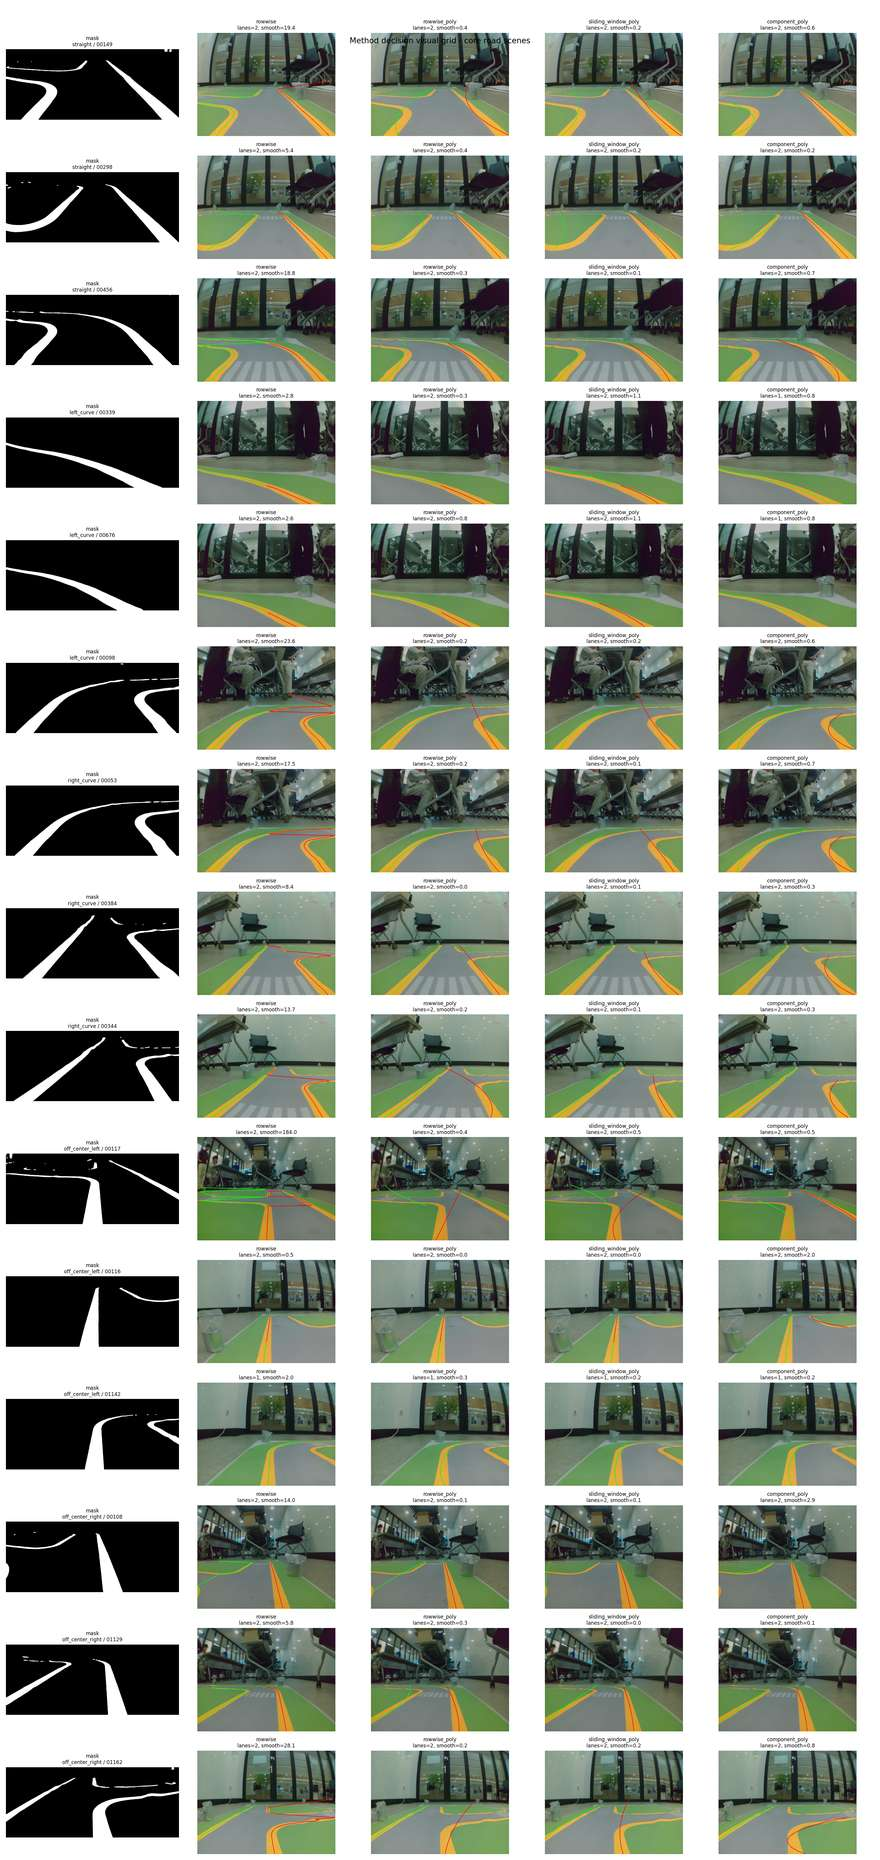

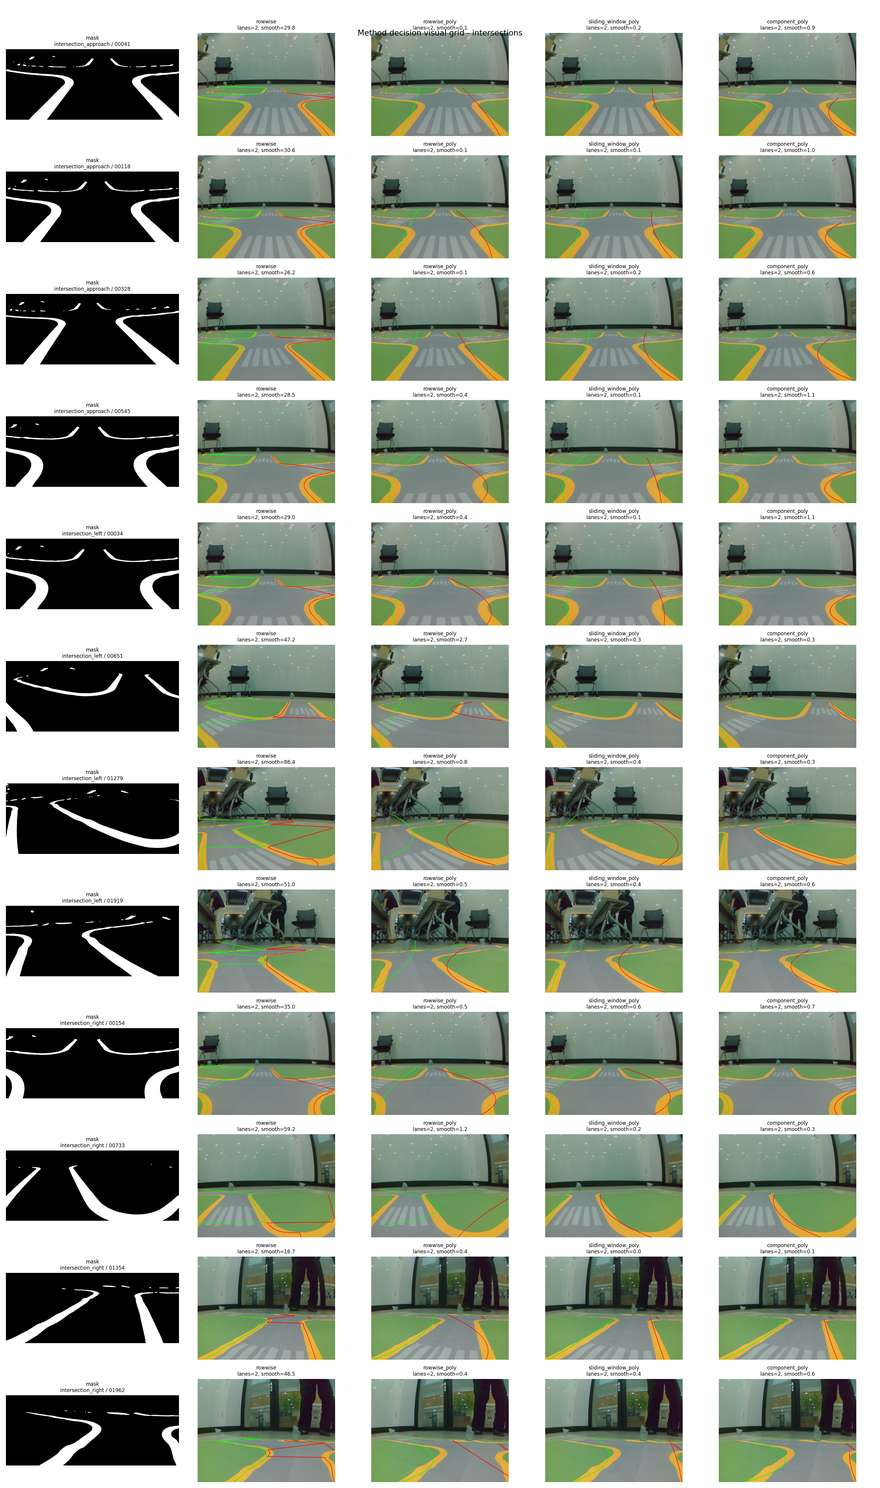

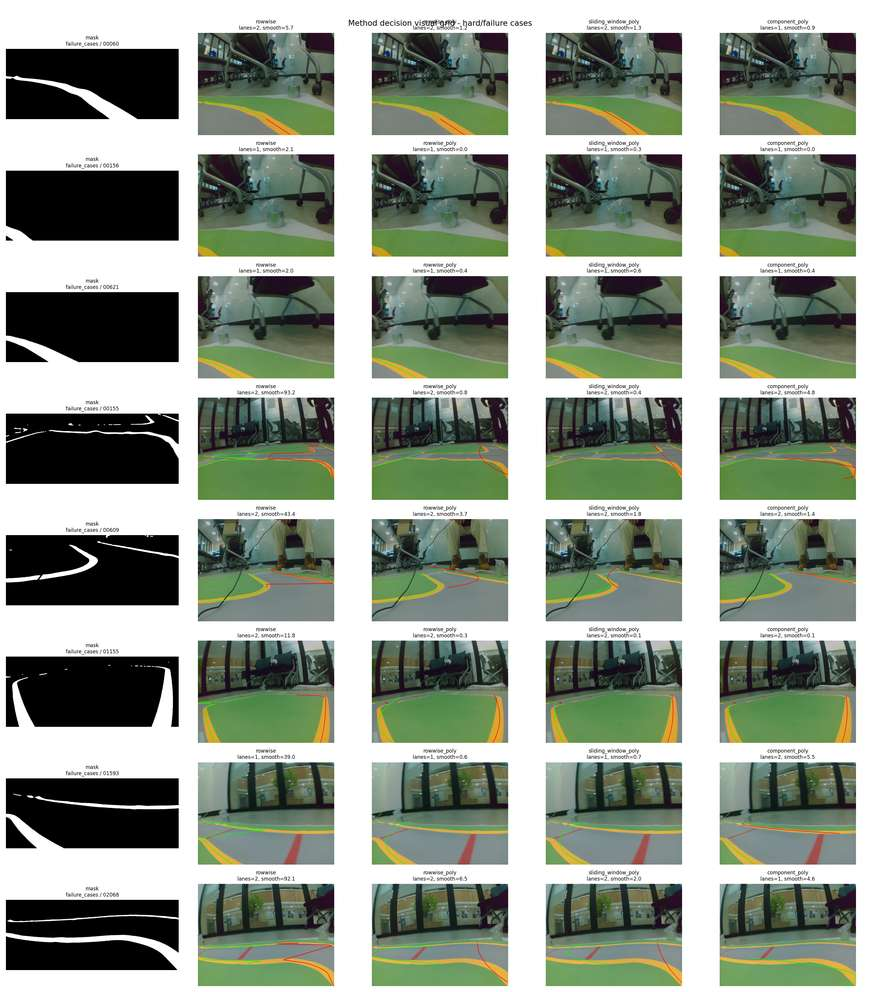

In [9]:
display(Image(filename=str(core_grid)))
display(Image(filename=str(intersection_grid)))
display(Image(filename=str(hard_grid)))


## 7. Component method 내부 sweep

만약 최종 후보가 `component_poly`라면, method 자체도 고정값이 아니라 내부 파라미터를 조절할 수 있다. 여기서는 `min_area`, `min_height`, `y_step`, `degree`를 작은 grid로 훑어서 component 방식 내부 최적 후보를 찾는다.


In [10]:
component_grid = []
for min_area in [120, 250, 450, 700]:
    for min_height in [50, 80, 120]:
        for y_step in [6, 8, 10]:
            cfg = {"method": "component_poly", "y_step": y_step, "min_run_width": 4, "min_points": 8, "min_area": min_area, "min_height": min_height, "degree": 2}
            tmp = pd.DataFrame([diagnostics_for(row, "component_poly", cfg) for row in sample_rows])
            two_lane_rate = safe_mean(tmp["two_lane"])
            one_or_more_rate = safe_mean(tmp["one_or_more"])
            no_lane_rate = safe_mean(tmp["no_lane"])
            span_norm = float(np.nanmedian(tmp["median_y_span"]) / pc.GEOM.visible_height)
            smooth_median = float(np.nanmedian(tmp["median_smoothness"]))
            smooth_penalty = float(min(1.0, smooth_median / 12.0)) if not np.isnan(smooth_median) else 1.0
            mask_support = safe_mean(tmp["mask_support"])
            duplicate_component_rate = safe_mean(tmp["duplicate_component_risk"])
            crossing_rate = safe_mean(tmp["crossing_risk"])
            small_gap_rate = safe_mean(tmp["small_gap_risk"])
            scene_balance = min(safe_mean(sg["one_or_more"]) for _, sg in tmp.groupby("scene"))
            score = 30 * one_or_more_rate + 20 * two_lane_rate + 15 * span_norm + 15 * mask_support + 10 * scene_balance - 35 * duplicate_component_rate - 25 * crossing_rate - 15 * small_gap_rate - 10 * smooth_penalty
            component_grid.append({**cfg, "two_lane_rate": two_lane_rate, "one_or_more_rate": one_or_more_rate, "no_lane_rate": no_lane_rate, "scene_balance": scene_balance, "median_y_span": float(np.nanmedian(tmp["median_y_span"])), "median_smoothness": smooth_median, "mask_support": mask_support, "duplicate_component_rate": duplicate_component_rate, "crossing_rate": crossing_rate, "small_gap_rate": small_gap_rate, "conservative_label_score": score})

component_df = pd.DataFrame(component_grid).sort_values("conservative_label_score", ascending=False)
display(component_df.head(12))
component_df.to_csv(pc.REPORTS / "04_component_poly_param_sweep.csv", index=False, encoding="utf-8-sig")
best_component = component_df.iloc[0].to_dict()
print("best component cfg:", {k: best_component[k] for k in ["method", "y_step", "min_run_width", "min_points", "min_area", "min_height", "degree"]})


,method,y_step,min_run_width,min_points,min_area,min_height,degree,two_lane_rate,one_or_more_rate,no_lane_rate,scene_balance,median_y_span,median_smoothness,mask_support,duplicate_component_rate,crossing_rate,small_gap_rate,conservative_label_score
24,component_poly,6,4,8,450,120,2,0.722222,1.0,0.0,1.0,330.0,0.323541,0.921248,0.0,0.018519,0.018519,76.645592
33,component_poly,6,4,8,700,120,2,0.722222,1.0,0.0,1.0,330.0,0.323541,0.921248,0.0,0.018519,0.018519,76.645592
15,component_poly,6,4,8,250,120,2,0.722222,1.0,0.0,1.0,330.0,0.323541,0.921248,0.0,0.018519,0.018519,76.645592
6,component_poly,6,4,8,120,120,2,0.722222,1.0,0.0,1.0,330.0,0.323541,0.921248,0.0,0.018519,0.018519,76.645592
25,component_poly,8,4,8,450,120,2,0.722222,1.0,0.0,1.0,328.0,0.562346,0.923081,0.0,0.018519,0.018519,76.417155
34,component_poly,8,4,8,700,120,2,0.722222,1.0,0.0,1.0,328.0,0.562346,0.923081,0.0,0.018519,0.018519,76.417155
16,component_poly,8,4,8,250,120,2,0.722222,1.0,0.0,1.0,328.0,0.562346,0.923081,0.0,0.018519,0.018519,76.417155
7,component_poly,8,4,8,120,120,2,0.722222,1.0,0.0,1.0,328.0,0.562346,0.923081,0.0,0.018519,0.018519,76.417155
12,component_poly,6,4,8,250,80,2,0.759259,1.0,0.0,1.0,328.5,0.326785,0.920427,0.0,0.046296,0.046296,76.217519
21,component_poly,6,4,8,450,80,2,0.759259,1.0,0.0,1.0,328.5,0.326785,0.920427,0.0,0.046296,0.046296,76.217519


best component cfg: {'method': 'component_poly', 'y_step': 6, 'min_run_width': 4, 'min_points': 8, 'min_area': 450, 'min_height': 120, 'degree': 2}


## 8. 최종 후보 config 저장

이 노트북은 기존 `field2_builder_v2_pairing.json`을 바로 덮어쓰지 않는다. 대신 결정 근거를 담은 report와 `field2_builder_v2_pairing_decision.json`을 저장한다. 시각 pack을 보고 문제가 없으면, 다음 단계에서 이 decision config를 실제 dataset build config로 승격하면 된다.


In [11]:
selected_method = str(summary_df.iloc[0]["method"])
selected_pairing = dict(METHOD_CONFIGS[selected_method])
best_component_pairing = {"method": "component_poly", "y_step": int(best_component["y_step"]), "min_run_width": int(best_component["min_run_width"]), "min_points": int(best_component["min_points"]), "min_area": int(best_component["min_area"]), "min_height": int(best_component["min_height"]), "degree": int(best_component["degree"])}
final_recommendation = best_component_pairing if selected_method == "component_poly" else selected_pairing

decision_config = dict(base_config)
decision_config["name"] = "field2_builder_v2_pairing_method_decision"
decision_config["sample_policy"] = {"eval_per_scene": EVAL_PER_SCENE, "eval_samples": len(sample_rows), "visual_per_scene": VISUAL_PER_SCENE}
decision_config["pairing_method_candidates"] = METHOD_CONFIGS
decision_config["pairing"] = final_recommendation
decision_config["pairing_component_poly_best"] = best_component_pairing
decision_config["method_decision"] = {"selected_by_conservative_score": selected_method, "selected_pairing": final_recommendation, "component_poly_best": best_component_pairing, "note": "Inspect visual grids before replacing field2_builder_v2_pairing.json."}

report = {"selected_by_conservative_score": selected_method, "selected_pairing": final_recommendation, "component_poly_best": best_component_pairing, "summary": summary_df.to_dict(orient="records"), "scene_metrics": scene_df.to_dict(orient="records"), "visual_outputs": [str(core_grid), str(intersection_grid), str(hard_grid)], "raw_diagnostics_csv": str(raw_diag_path)}
config_path = PIPELINE_ROOT / "configs" / "field2_builder_v2_pairing_decision.json"
report_path = pc.REPORTS / "04_method_sample_decision_report.json"
pc.write_json(config_path, decision_config)
pc.write_json(report_path, report)
print("decision config:", config_path)
print("report:", report_path)
print("selected by conservative score:", selected_method)
print("selected pairing:", final_recommendation)
print("component best:", best_component_pairing)


decision config: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\05_lane_finetune_dataset_pipeline\configs\field2_builder_v2_pairing_decision.json
report: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\05_lane_finetune_dataset_pipeline\reports\04_method_sample_decision_report.json
selected by conservative score: component_poly
selected pairing: {'method': 'component_poly', 'y_step': 6, 'min_run_width': 4, 'min_points': 8, 'min_area': 450, 'min_height': 120, 'degree': 2}
component best: {'method': 'component_poly', 'y_step': 6, 'min_run_width': 4, 'min_points': 8, 'min_area': 450, 'min_height': 120, 'degree': 2}


## 9. 결과 메모

이번 재비교에서는 기존 04번보다 샘플을 늘려 씬당 12장, 총 108장을 사용했다. 결론은 `component_poly`를 기본 후보로 채택하는 쪽이 가장 타당하다.

핵심 수치는 아래와 같다.

| method | two-lane rate | mask support | duplicate component risk | crossing risk | conservative score |
|---|---:|---:|---:|---:|---:|
| component_poly | 0.759 | 0.922 | 0.000 | 0.046 | 76.03 |
| rowwise_poly | 0.926 | 0.671 | 0.213 | 0.102 | 67.60 |
| sliding_window_poly | 0.889 | 0.668 | 0.204 | 0.104 | 67.32 |
| rowwise | 0.926 | 1.000 | 0.157 | 0.102 | 65.11 |

해석은 다음과 같다.

- `rowwise_poly`와 `sliding_window_poly`는 두 선을 더 자주 만든다. 하지만 같은 물리 노란선을 초록/빨강 두 lane으로 나누는 `duplicate component risk`가 각각 0.213, 0.204로 높다.
- `component_poly`는 two-lane rate가 0.759로 낮지만, duplicate component risk가 0.000이다. 즉 틀린 두 선을 억지로 만드는 대신, 더 보수적으로 실제 연결된 노란 component를 lane으로 만든다.
- 시각 비교 pack에서도 core/curve/intersection 구간에서 `component_poly`가 한 물리 차선에 초록/빨강이 섞이는 문제가 가장 적다. 특히 fine-tuning용 pseudo label에서는 양보다 label의 정합성이 더 중요하므로 이 방향이 더 안전하다.
- component 내부 sweep 결과, 현재 추천 파라미터는 `{"method": "component_poly", "y_step": 6, "min_run_width": 4, "min_points": 8, "min_area": 450, "min_height": 120, "degree": 2}`이다.

저장된 산출물은 다음과 같다.

- `reports/04_method_sample_decision_report.json`
- `reports/04_method_sample_summary.csv`
- `reports/04_method_sample_by_scene.csv`
- `reports/04_component_poly_param_sweep.csv`
- `configs/field2_builder_v2_pairing_decision.json`
- `outputs/04_method_sample_grid_core.png`
- `outputs/04_method_sample_grid_intersections.png`
- `outputs/04_method_sample_grid_hard_cases.png`

기존 `field2_builder_v2_pairing.json`은 감사 추적을 위해 아직 덮어쓰지 않았다. 다음 단계에서 이 결과를 확인한 뒤, `field2_builder_v2_pairing_decision.json`을 실제 preview/build config로 승격하면 된다.
